In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Week-2

**Note to Learners**:

- For questions that involve plotting, just enter $0$ as the answer in the portal.
- For numerical questions, there are two parts. The first part expects you to compute some quantity, say a parameter of a machine learning model. The second part will require you to convert this quantity (if it is not a scalar) into a scalar so that it can be entered as the answer on the portal to the corresponding NAT question.



## Dataset

Run the cell given below to generate the data-matrix $\mathbf{X}$, which is of shape $(n, d)$, where $n$ denotes the number of samples and $d$ denotes the number of features. Ignore the vector $y$. You will be using this dataset for the rest of the assignment. Do not edit this cell.

In [2]:
from sklearn.datasets import make_circles

X, y = make_circles(n_samples=1000, factor=0.9, noise=0.2, random_state=0)

## Problem 1
Plot the dataset using matplotlib.

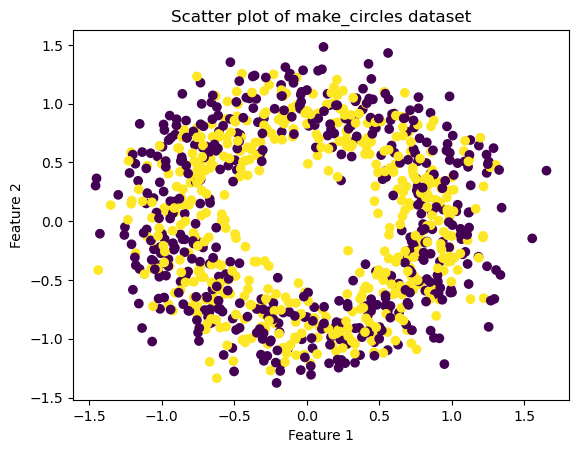

In [8]:
# Enter your solution here
plt.scatter(X[:, 0], X[:, 1], c = y) # c is used to color the points based on their class labels
plt.title("Scatter plot of make_circles dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## Problem 2
How many samples are there in the dataset?


In [13]:
# Enter your solution here
print("Shape of X:", X.shape)
print("Number of samples:", X.shape[0])

Shape of X: (1000, 2)
Number of samples: 1000


## Problem 3
How many features are there in the dataset?

In [12]:
# Enter your solution here
print("Number of features:", X.shape[1])

Number of features: 2


## Problem 4
Find the kernel matrix $K$ using the polynomial kernel with degree $2$.

<u>Conversion</u>

Enter the following quantity as your answer correct to two decimal places:

$$
\cfrac{1}{n} \sqrt{\sum \limits_{i = 1}^{n} \sum \limits_{j = 1}^{n} (K_{ij})^2}
$$

In [22]:
# Enter your solution here
n = X.shape[0]
# Polynomial kernel (xᵀy + 1)^2
# K = (X * X.T + 1) ** 2
K = np.matmul(X, X.T) ** 2

ans  = np.sqrt(np.sum(K**2)) / n
print("Answer:", ans) 


Answer: 0.6980978557915198


## Problem 5
Find the kernel matrix $K$ using the Gaussian kernel with parameter $\sigma = 2$.

<u>Conversion</u>

Enter the following quantity as your answer correct to two decimal places:

$$
\cfrac{1}{n} \sqrt{\sum \limits_{i = 1}^{n} \sum \limits_{j = 1}^{n} (K_{ij})^2}
$$

K(xi​,xj​)=exp(−2σ2∥xi​−xj​∥2​)

In [23]:
# Enter your solution here
# Gussain kernel function :  f(X , Y) = exp(-||X - Y||^2 / (2 * sigma^2))
n = X.shape[0]

sigma = 2

# Pairwise squared Euclidean distances
sq_norms = np.sum(X**2, axis=1)

dist_sq = (
    sq_norms[:, None]
    + sq_norms[None, :]
    - 2 * X @ X.T
)

# Gaussian Kernel
K = np.exp(-dist_sq / (2 * sigma**2))

ans = np.sqrt(np.sum(K**2)) / n

print(round(ans, 2))

0.81


## Problem 6
Find the center of the kernel matrix $K$ obtained in problem 2. Call this centered matrix $KC$.

<u>Conversion</u>

Enter the following quantity as your answer correct to two decimal places:

$$
\cfrac{1}{n} \sqrt{\sum \limits_{i = 1}^{n} \sum \limits_{j = 1}^{n} KC_{ij}^2}
$$

In [24]:
# Enter your solution here
n = X.shape[0]

# Polynomial kernel
K = (X @ X.T + 1) ** 2

I = np.ones((n, n)) / n

# Center Kernel Matrix
Kc = K - I @ K - K @ I + I @ K @ I

ans = np.sqrt(np.sum(Kc**2)) / n

print(round(ans, 2))

1.45


## Problem 7
Find the projections (scalar) of all the data points on to the first two principal components obtained using polynomial kernel of degree 2.

<u>Conversion</u>

if $\alpha_1, \alpha_2, ..., \alpha_n$ are the prjections on the first PC and $\beta_1, \beta_2, ..., \beta_n$ are the projections on the second PC, enter the following quantity as your answer correct to two decimal places:

$$\sum_{i = 1}^{n} \alpha_i + \sum_{i = 1}^{n} \beta_i$$

In [25]:
# Enter your solution here
n = X.shape[0]

# Polynomial Kernel
K = (X @ X.T + 1) ** 2

I = np.ones((n, n)) / n

# Center kernel
Kc = K - I @ K - K @ I + I @ K @ I

# Eigen decomposition
eigenvalues, eigenvectors = np.linalg.eigh(Kc)

# Sort in descending order
idx = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Normalize eigenvectors
alphas = eigenvectors[:, :2] / np.sqrt(eigenvalues[:2])

# Projection
projection = Kc @ alphas

ans = np.mean(np.sum(projection**2, axis=1))

print(round(ans, 2))

1.97
